In [ ]:
# импортирование основных библиотек

import os
import math
import time
import random
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision



# -----------------------
# Вывод графиков
# -----------------------
# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
def set_seed(seed: int = RANDOM_STATE) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)
print('pandas:', pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)



FAST_MODE = True
DATA_DIR = "./data"
BATCH_SIZE = 64 if FAST_MODE else 128
EPOCHS = 10 if FAST_MODE else 12

Device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


#### Данные и первичный анализ

In [2]:
df = pd.read_csv("S12-hw-dataset.csv")
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [3]:
print("До преобразования: ")
df.info()

df["date"] = pd.to_datetime(df["date"], errors='coerce')
print("\nПосле преобразования: ")
df.info()

До преобразования: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    4320 non-null   object 
 1   target  4320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 67.6+ KB

После преобразования: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


In [4]:
df = df.sort_values(by="date")
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


Число наблюдений: 4320
Диапозон дат: от 2025-01-01 00:00:00 до 2025-06-29 23:00:00
Число пропусков по колонкам: date - 0; target - 0


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


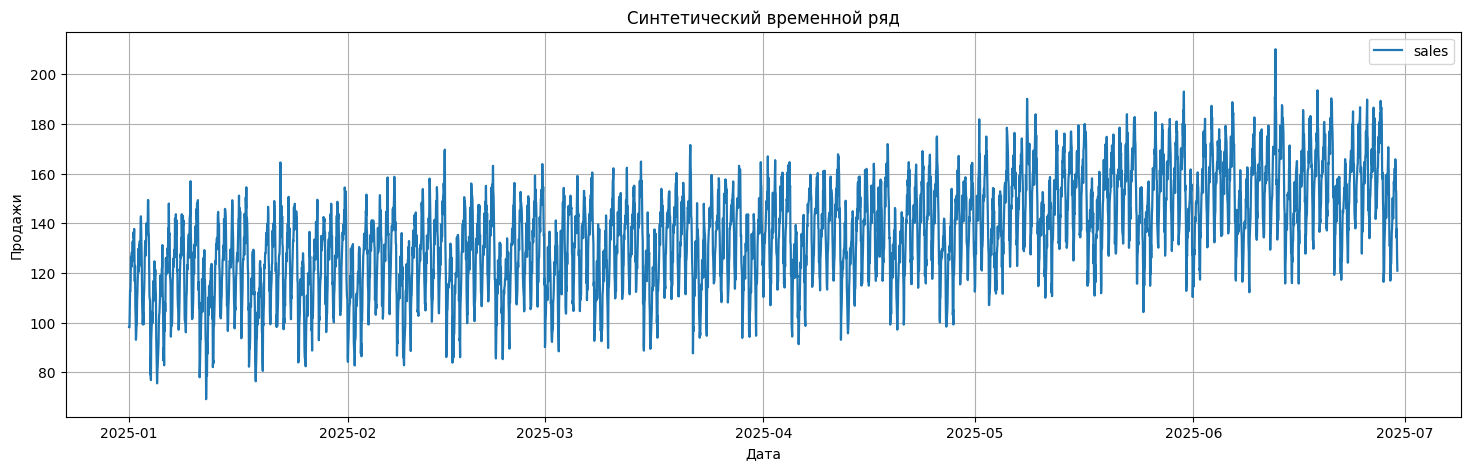

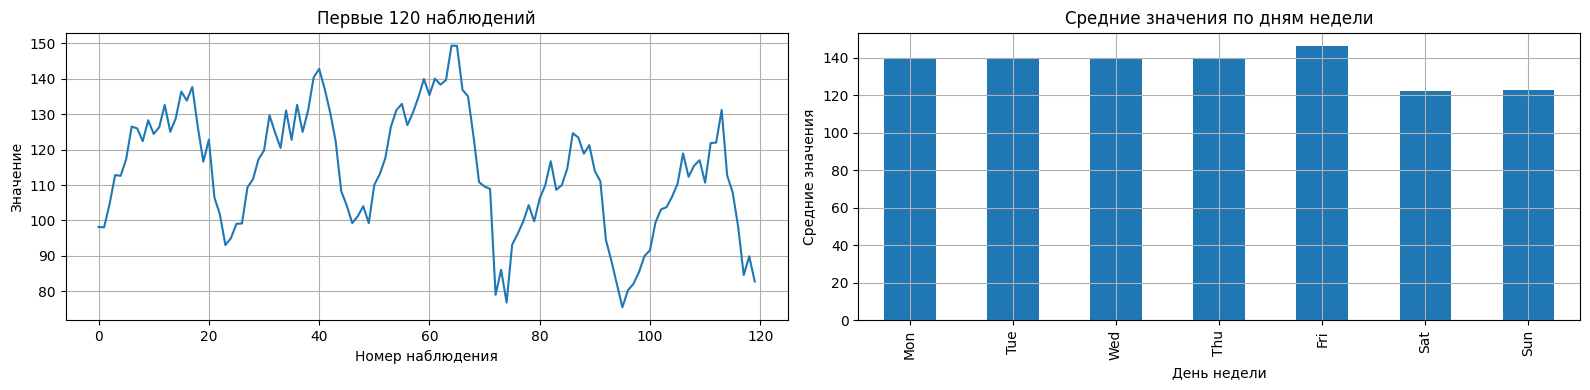

In [5]:
print(f"Число наблюдений: {df["date"].size}")
print(f"Диапозон дат: от {df["date"].min()} до {df["date"].max()}")
print(f"Число пропусков по колонкам: date - {df["date"].isna().sum()}; target - {df["target"].isna().sum()}")


# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots(figsize=(18,5))
ax.plot(df["date"], df["target"], lw=1.6, label="sales")
ax.set_title("Синтетический временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 наблюдений")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Значение")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние значения по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средние значения")

plt.tight_layout()
plt.show()

Можно заметить тренд на небольшой долгосрочный рост.   
Есть недельная сезонность - в выходные в среднем показатели меньше.   
Присутствуют резкие всплески значений в обе стороны.  

#### Корректный temporal split

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


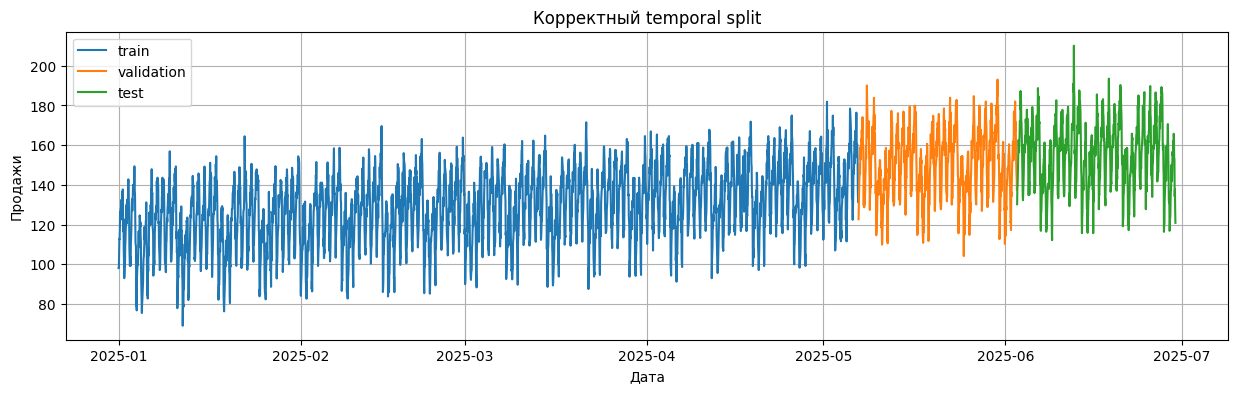

In [6]:
# Делим наши данные

@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.savefig('artifacts/figures/series_split.png')
plt.show()


Т.к. мы предсказываем временной ряд у нас работает логика: "Используя прошлое, предсказать будущее".  
Если перемешивать значения случайно, то в train попадут значения как из прошлого, так и из будущего, а в test попадут ранние данные.  
Таким образом время перемешается, чего быть не должно.  

#### Признаки для baseline-моделей

In [7]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 2, 3, 7, 14, 24]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_24"] = out[target_col].shift(1).rolling(window=24).mean()
    out["rolling_std_24"] = out[target_col].shift(1).rolling(window=24).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_24,rolling_mean_7,rolling_std_7,rolling_mean_24,rolling_std_24
0,2025-01-02 00:00:00,95.00,3,1,0.433884,-0.900969,0.5,0.866025,93.04,101.72,106.54,137.71,124.43,98.14,114.964286,15.480559,119.130000,12.922052
1,2025-01-02 01:00:00,99.05,3,1,0.433884,-0.900969,0.5,0.866025,95.00,93.04,101.72,126.32,126.35,98.07,108.862857,13.282189,118.999167,13.157562
2,2025-01-02 02:00:00,99.14,3,1,0.433884,-0.900969,0.5,0.866025,99.05,95.00,93.04,116.59,132.63,104.70,104.967143,11.134058,119.040000,13.091139
3,2025-01-02 03:00:00,109.33,3,1,0.433884,-0.900969,0.5,0.866025,99.14,99.05,95.00,122.83,125.04,112.81,102.474286,9.993064,118.808333,13.401457
4,2025-01-02 04:00:00,111.64,3,1,0.433884,-0.900969,0.5,0.866025,109.33,99.14,99.05,106.54,128.87,112.62,100.545714,5.856307,118.663333,13.487728


In [8]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_24",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_24", "rolling_std_24",
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train_base = train_feat[feature_cols]
y_train_base = train_feat[target_col]

X_val_base = val_feat[feature_cols]
y_val_base = val_feat[target_col]

X_test_base = test_feat[feature_cols]
y_test_base = test_feat[target_col]

print("Размерности:")
print("X_train_base:", X_train_base.shape, "| y_train_base:", y_train_base.shape)
print("X_val_base:  ", X_val_base.shape, "| y_val_base:  ", y_val_base.shape)
print("X_test_base: ", X_test_base.shape, "| y_test_base: ", y_test_base.shape)

Размерности:
X_train_base: (3007, 16) | y_train_base: (3007,)
X_val_base:   (644, 16) | y_val_base:   (644,)
X_test_base:  (645, 16) | y_test_base:  (645,)


#### Оконное представление для GRU

In [9]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

WINDOW_SIZE = 96  # Глубина контекста: модель смотрит на 48 часа в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [hour1..hour28], y = hour29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 48
        y.append(series_2d[i + window_size, 0])         # Цель: час 49
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train_GRU, y_train_GRU = make_windows(train_scaled, WINDOW_SIZE)
X_val_GRU, y_val_GRU = make_windows(val_scaled, WINDOW_SIZE)
X_test_GRU, y_test_GRU = make_windows(test_scaled, WINDOW_SIZE)

print("X_train_GRU:", X_train_GRU.shape, "y_train_GRU:", y_train_GRU.shape)
print("X_val_GRU  :", X_val_GRU.shape, "y_val_GRU  :", y_val_GRU.shape)
print("X_test_GRU :", X_test_GRU.shape, "y_test_GRU :", y_test_GRU.shape)

X_train_GRU: (2928, 96, 1) y_train_GRU: (2928,)
X_val_GRU  : (552, 96, 1) y_val_GRU  : (552,)
X_test_GRU : (552, 96, 1) y_test_GRU : (552,)


Форма одного окна: (96, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -2.59371


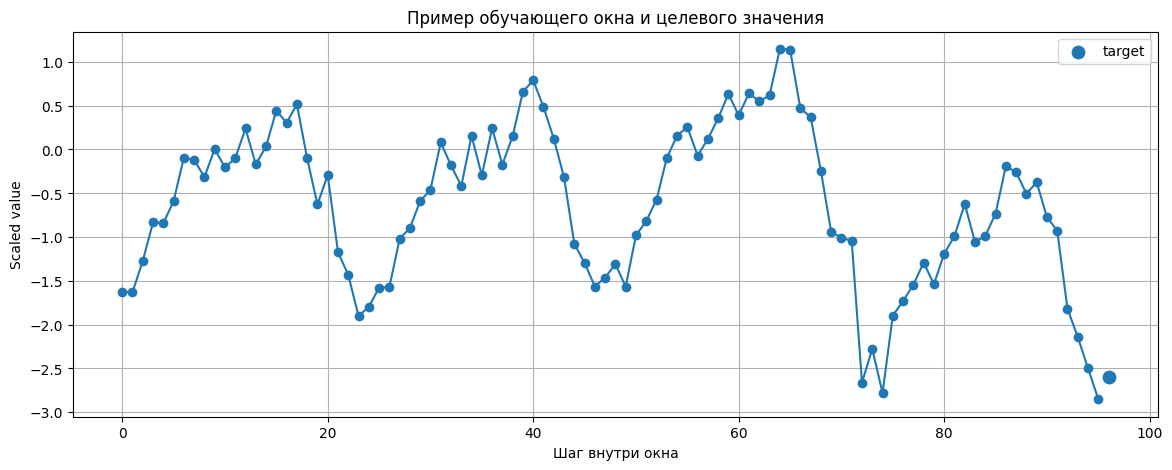

In [10]:
sample_idx = 0

print("Форма одного окна:", X_train_GRU[sample_idx].shape)
print("Первые 5 значений окна:", X_train_GRU[sample_idx][:5].ravel())
print("Цель:", y_train_GRU[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(WINDOW_SIZE), X_train_GRU[sample_idx].ravel(), marker="o")
ax.scatter([WINDOW_SIZE], [y_train_GRU[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [11]:
set_seed()
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train_GRU, y_train_GRU)
val_ds = TimeSeriesDataset(X_val_GRU, y_val_GRU)
test_ds = TimeSeriesDataset(X_test_GRU, y_test_GRU)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 96, 1])
Batch y: torch.Size([64])


In [12]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [13]:
#-----------------
# Функции для GRU
#-----------------


def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=DEVICE):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


#---------------------
# Функции для Baseline
#---------------------


# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])





## Эксперименты

In [14]:
# Создание датафрейма для записи результатов
runs = pd.DataFrame(columns=['experiment_id','task','dataset','seed',
                             'split_summary', 'window_size','horizon',
                             'model_summary', 'features_summary',
                             'scaler', 'optimizer','lr','epochs_trained',
                             'best_val_mae','best_val_rmse', 'best_val_mape',
                             'test_mae','test_rmse','test_mape',
                             'notes'
                             ])
print(runs)

Empty DataFrame
Columns: [experiment_id, task, dataset, seed, split_summary, window_size, horizon, model_summary, features_summary, scaler, optimizer, lr, epochs_trained, best_val_mae, best_val_rmse, best_val_mape, test_mae, test_rmse, test_mape, notes]
Index: []


#### B1+B2 (naive-last + moving-average)

In [15]:
#B1 + B2

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()


B1_val_results = evaluate_regression(y_val_base, val_pred_naive, "Naive (lag_1)")
B2_val_results = evaluate_regression(y_val_base, val_pred_ma7, "MovingAverage(7)")
baseline_results_val = pd.concat([
    B1_val_results,
    B2_val_results,
], ignore_index=True)

print("Validation:")
display(baseline_results_val)


B1_data = {'experiment_id': 'B1',
           'task': 'forecasting',
           'dataset': 'S12-hw-dataset.csv',
           'seed': RANDOM_STATE,
           'split_summary': '70/15/15 temporal split',
            'window_size': None,
            'horizon': 1,
            'model_summary': 'Baseline модель берущая предыдущее значение в качестве предсказания', 
            'features_summary': 'last value (lag_1)',
            'scaler': None, 
            'optimizer': None,
            'lr': None,
            'epochs_trained': None,
            'best_val_mae': B1_val_results.to_dict()['MAE'][0],
            'best_val_rmse': B1_val_results.to_dict()['RMSE'][0], 
            'best_val_mape': B1_val_results.to_dict()['MAPE_%'][0],
            'test_mae': None,
            'test_rmse': None,
            'test_mape': None,
            'notes': 'weak model',
        }       

runs = pd.concat([runs, pd.DataFrame([B1_data])], ignore_index=True)
B2_data = {'experiment_id': 'B2',
           'task': 'forecasting',
           'dataset': 'S12-hw-dataset.csv',
           'seed': RANDOM_STATE,
           'split_summary': '70/15/15 temporal split',
            'window_size': None,
            'horizon': 1,
            'model_summary': 'Baseline модель берущая среднее нескольких последних наблюдений', 
            'features_summary': 'Moving average(7) (rolling_mean_7)',
            'scaler': None, 
            'optimizer': None,
            'lr': None,
            'epochs_trained': None,
            'best_val_mae': B2_val_results.to_dict()['MAE'][0],
            'best_val_rmse': B2_val_results.to_dict()['RMSE'][0], 
            'best_val_mape': B2_val_results.to_dict()['MAPE_%'][0],
            'test_mae': None,
            'test_rmse': None,
            'test_mape': None,
            'notes': 'weak model',
        }       

runs = pd.concat([runs, pd.DataFrame([B2_data])], ignore_index=True)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.444565,8.209954,4.395541
1,MovingAverage(7),12.714401,15.237329,8.823295


C:\Users\ivanv\AppData\Local\Temp\ipykernel_21004\1000461505.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs = pd.concat([runs, pd.DataFrame([B1_data])], ignore_index=True)


#### B3 (ridge-lag-features)

In [16]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler_Ridge = StandardScaler()
X_train_scaled = scaler_Ridge.fit_transform(X_train_base)
X_val_scaled = scaler_Ridge.transform(X_val_base)
X_test_scaled = scaler_Ridge.transform(X_test_base)


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_base)

val_pred_ridge = ridge.predict(X_val_scaled)

# Сравниваем модели на validation и test в единой таблице метрик.
B3_val_results = evaluate_regression(y_val_base, val_pred_ridge, "Ridge")
val_results = pd.concat([
    baseline_results_val,
    B3_val_results
], ignore_index=True).sort_values("MAE").reset_index(drop=True)


print("Validation:")
display(val_results)


B3_data = {'experiment_id': 'B3',
           'task': 'forecasting',
           'dataset': 'S12-hw-dataset.csv',
           'seed': RANDOM_STATE,
           'split_summary': '70/15/15 temporal split',
            'window_size': None,
            'horizon': 1,
            'model_summary': 'Baseline линейная модель с L2-регуляризацией', 
            'features_summary': f'{feature_cols}',
            'scaler': 'scaler.fit_transform на features', 
            'optimizer': None,
            'lr': None,
            'epochs_trained': None,
            'best_val_mae': B3_val_results.to_dict()['MAE'][0],
            'best_val_rmse': B3_val_results.to_dict()['RMSE'][0], 
            'best_val_mape': B3_val_results.to_dict()['MAPE_%'][0],
            'test_mae': None,
            'test_rmse': None,
            'test_mape': None,
            'notes': 'very good model',
        }       

runs = pd.concat([runs, pd.DataFrame([B3_data])], ignore_index=True)


Validation:


,model,MAE,RMSE,MAPE_%
0,Ridge,5.159604,6.674084,3.482519
1,Naive (lag_1),6.444565,8.209954,4.395541
2,MovingAverage(7),12.714401,15.237329,8.823295


#### R1 (gru-forecast)

GRU  params: 37889
Epoch 01 | train_loss=0.7087 | val_loss=0.6567
Epoch 02 | train_loss=0.3128 | val_loss=0.3048
Epoch 03 | train_loss=0.1875 | val_loss=0.1943
Epoch 04 | train_loss=0.1739 | val_loss=0.1748
Epoch 05 | train_loss=0.1736 | val_loss=0.1929
Epoch 06 | train_loss=0.1657 | val_loss=0.2288
Epoch 07 | train_loss=0.1622 | val_loss=0.1947
Epoch 08 | train_loss=0.1611 | val_loss=0.2276
Epoch 09 | train_loss=0.1579 | val_loss=0.2017
Epoch 10 | train_loss=0.1542 | val_loss=0.2037
Epoch 11 | train_loss=0.1528 | val_loss=0.2083
Epoch 12 | train_loss=0.1535 | val_loss=0.1920
Epoch 13 | train_loss=0.1482 | val_loss=0.2094
Epoch 14 | train_loss=0.1421 | val_loss=0.1794
Epoch 15 | train_loss=0.1276 | val_loss=0.2062
Epoch 16 | train_loss=0.1202 | val_loss=0.1779
Epoch 17 | train_loss=0.1119 | val_loss=0.1735
Epoch 18 | train_loss=0.1111 | val_loss=0.1604
Epoch 19 | train_loss=0.1086 | val_loss=0.1653
Epoch 20 | train_loss=0.1044 | val_loss=0.1423
Epoch 21 | train_loss=0.1077 | val_loss=0

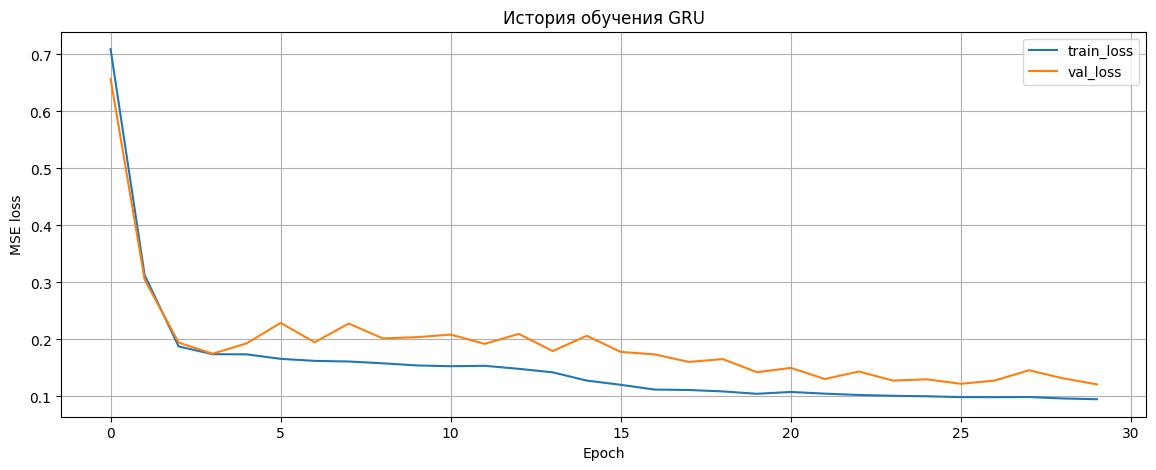

In [17]:
# Обучаем GRU
LR=5e-4
EPOCHS=30
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2, dropout=0.4).to(DEVICE)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=DEVICE)


fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

torch.save(gru_model.state_dict(), 'artifacts/best_gru.pt')




In [18]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape}

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, DEVICE)

# Восстанавливаем исходный масштаб
val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)


# Вычисляем метрики для каждой модели и сортируем по RMSE
val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
)#.sort_values("RMSE")

val_results = pd.concat([
    val_results,
    val_metrics
], ignore_index=True).sort_values("MAE").reset_index(drop=True)
display(val_results)

# Сохранение весов модели
torch.save(gru_model.state_dict(), 'artifacts/best_gru.pt')

   

,model,MAE,RMSE,MAPE_%
0,GRU,4.948048,6.443151,3.322239
1,Ridge,5.159604,6.674084,3.482519
2,Naive (lag_1),6.444565,8.209954,4.395541
3,MovingAverage(7),12.714401,15.237329,8.823295


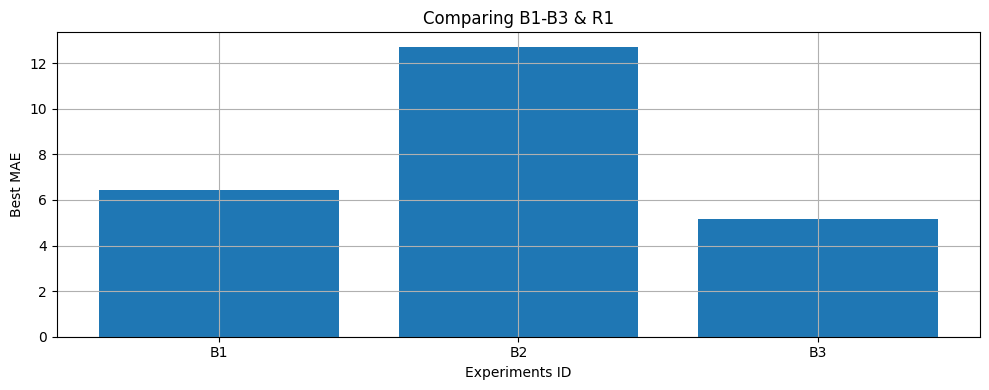

In [19]:
# Сравнение B1-B3 и R1 по best_val_accuracy
plt.figure(figsize=(10, 4))
plt.bar(runs["experiment_id"],runs["best_val_mae"])
plt.xlabel("Experiments ID")
plt.ylabel("Best MAE")
plt.title("Comparing B1-B3 & R1")
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

In [20]:
# Оценка моделей на TEST (финальная проверка, на которую модель не смотрела во время обучения)

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, DEVICE)
# Восстанавливаем исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)

# Вычисляем финальные метрики
test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
).sort_values("RMSE")

test_metrics



R1_data = {'experiment_id': 'R1',
           'task': 'forecasting',
           'dataset': 'S12-hw-dataset.csv',
           'seed': RANDOM_STATE,
           'split_summary': '70/15/15 temporal split',
            'window_size': WINDOW_SIZE,
            'horizon': 1,
            'model_summary': 'GRU модель', 
            'features_summary': 'date',
            'scaler': 'scaler.fit_transform на target', 
            'optimizer': 'Adam',
            'lr': 5e-4,
            'epochs_trained': EPOCHS,
            'best_val_mae': val_metrics.to_dict()['MAE'][0],
            'best_val_rmse': val_metrics.to_dict()['RMSE'][0], 
            'best_val_mape': val_metrics.to_dict()['MAPE_%'][0],
            'test_mae': test_metrics.to_dict()['MAE'][0],
            'test_rmse': test_metrics.to_dict()['RMSE'][0],
            'test_mape': test_metrics.to_dict()['MAPE_%'][0],
            'notes': "The Best model",
        }    

runs = pd.concat([runs, pd.DataFrame([R1_data])], ignore_index=True)
runs.to_csv("artifacts/runs.csv")
display(runs)



C:\Users\ivanv\AppData\Local\Temp\ipykernel_21004\1574449250.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs = pd.concat([runs, pd.DataFrame([R1_data])], ignore_index=True)


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,None,1,Baseline модель берущая предыдущее значение в ...,last value (lag_1),None,None,NaN,None,6.444565,8.209954,4.395541,NaN,NaN,NaN,weak model
1,B2,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,None,1,Baseline модель берущая среднее нескольких пос...,Moving average(7) (rolling_mean_7),None,None,NaN,None,12.714401,15.237329,8.823295,NaN,NaN,NaN,weak model
2,B3,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,None,1,Baseline линейная модель с L2-регуляризацией,"['dayofweek', 'month', 'dow_sin', 'dow_cos', '...",scaler.fit_transform на features,None,NaN,None,5.159604,6.674084,3.482519,NaN,NaN,NaN,very good model
3,R1,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,96,1,GRU модель,date,scaler.fit_transform на target,Adam,0.0005,30,4.948048,6.443151,3.322239,5.569043,7.197489,3.582019,The Best model


Лучшая модель на test: GRU


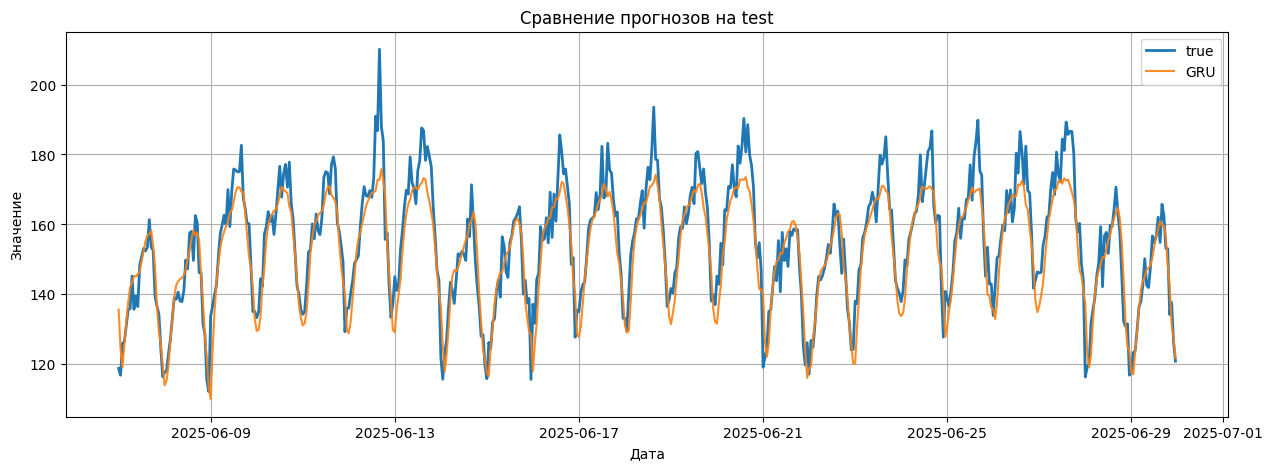

In [21]:
# Определяем лучшую модель и визуализируем результаты
best_model_name = test_metrics.iloc[0]["model"]
print("Лучшая модель на test:", best_model_name)

# Объединяем даты и предсказания в одной таблице
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[WINDOW_SIZE:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

In [22]:
# Сохранение конфига лучшей модели
best_config = runs.iloc[3].to_dict()
best_config.pop('experiment_id')

best_config['hidden_size'] = 64
best_config['batch_size'] = 64

#print(best_config)
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)
print("Saved:", "best_gru_config.json")

Saved: best_gru_config.json
